# U.S. Airline Operational Performance Analysis

**Author**: Ashwin Parthasarathy

**Dataset**: U.S. Bureau of Transportation Statistics - Reporting Carrier On-Time Performance

This project builds a reproducible Python data workflow to analyze recent U.S. airline operational performance. The analysis focuses on flight delays, cancellations, airports, carriers, routes, and temporal patterns using recent BTS flight operations data.

## 1. Setup
---

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)
print("Numpy: ", np.__version__)
print("Pandas: ", pd.__version__)

Numpy:  2.5.3
Pandas:  3.0.6


## 2. Data Ingestion
---

### Dataset Source and Scope

This analysis uses the U.S. Bureau of Transportation Statistics (BTS)
Reporting Carrier On-Time Performance dataset.

The working dataset covers January 2025 through July 2026. Raw monthly
BTS ZIP archives are downloaded reproducibly and converted to focused
Parquet files containing the operational fields required for this analysis.

The raw and processed datasets are excluded from Git because of their size.
The repository instead includes scripts to reproduce the local dataset.

In [3]:
PROJECT_ROOT = Path.cwd()
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

parquet_files = sorted(PROCESSED_DATA_DIR.glob("bts_flights_*.parquet"))

print(f"Monthly files found: {len(parquet_files)}")
print(f"First file: {parquet_files[0].name}")
print(f"Last file:  {parquet_files[-1].name}")

Monthly files found: 19
First file: bts_flights_2025_01.parquet
Last file:  bts_flights_2026_07.parquet


In [4]:
# Take inventory of all files and inspect for data sufficiency (no. of records, start date, end date)
monthly_inventory = []

for path in parquet_files:
    dates = pd.read_parquet(
        path,
        columns=["FlightDate"],
    )

    monthly_inventory.append(
        {
            "file": path.name,
            "rows": len(dates),
            "start_date": dates["FlightDate"].min(),
            "end_date": dates["FlightDate"].max(),
        }
    )

inventory_df = pd.DataFrame(monthly_inventory)
inventory_df

,file,rows,start_date,end_date
0,bts_flights_2025_01.parquet,539747,2025-01-01,2025-01-31
1,bts_flights_2025_02.parquet,504884,2025-02-01,2025-02-28
2,bts_flights_2025_03.parquet,600872,2025-03-01,2025-03-31
3,bts_flights_2025_04.parquet,583950,2025-04-01,2025-04-30
4,bts_flights_2025_05.parquet,605648,2025-05-01,2025-05-31
5,bts_flights_2025_06.parquet,611575,2025-06-01,2025-06-30
6,bts_flights_2025_07.parquet,631428,2025-07-01,2025-07-31
7,bts_flights_2025_08.parquet,602378,2025-08-01,2025-08-31
8,bts_flights_2025_09.parquet,562439,2025-09-01,2025-09-30
9,bts_flights_2025_10.parquet,605844,2025-10-01,2025-10-31


In [5]:
print(f"Total rows: {inventory_df['rows'].sum():,}")
print("Date range: ", inventory_df['start_date'].min(), " to ", inventory_df['end_date'].max())

Total rows: 11,121,962
Date range:  2025-01-01 00:00:00  to  2026-07-31 00:00:00


In [6]:
# Sample one month's data
sample_df = pd.read_parquet(parquet_files[0])

print(f"Shape: {sample_df.shape}")
sample_df.head()

Shape: (539747, 41)


,Year,Month,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,Flight_Number_Reporting_Airline,OriginAirportID,Origin,OriginCityName,OriginState,DestAirportID,Dest,DestCityName,DestState,CRSDepTime,DepTime,DepDelay,DepDelayMinutes,DepDel15,DepTimeBlk,TaxiOut,TaxiIn,CRSArrTime,ArrTime,ArrDelay,ArrDelayMinutes,ArrDel15,ArrTimeBlk,Cancelled,CancellationCode,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2025,1,3,2025-01-01,AA,19805,1,12478,JFK,"New York, NY",NY,12892,LAX,"Los Angeles, CA",CA,659,656.0,-3.0,0.0,0.0,0600-0659,23.0,9.0,1020,1013.0,-7.0,0.0,0.0,1000-1059,0.0,NaN,0.0,381.0,377.0,345.0,2475.0,NaN,NaN,NaN,NaN,NaN
1,2025,1,4,2025-01-02,AA,19805,1,12478,JFK,"New York, NY",NY,12892,LAX,"Los Angeles, CA",CA,659,652.0,-7.0,0.0,0.0,0600-0659,30.0,7.0,1020,1022.0,2.0,2.0,0.0,1000-1059,0.0,NaN,0.0,381.0,390.0,353.0,2475.0,NaN,NaN,NaN,NaN,NaN
2,2025,1,5,2025-01-03,AA,19805,1,12478,JFK,"New York, NY",NY,12892,LAX,"Los Angeles, CA",CA,659,652.0,-7.0,0.0,0.0,0600-0659,13.0,11.0,1020,1003.0,-17.0,0.0,0.0,1000-1059,0.0,NaN,0.0,381.0,371.0,347.0,2475.0,NaN,NaN,NaN,NaN,NaN
3,2025,1,6,2025-01-04,AA,19805,1,12478,JFK,"New York, NY",NY,12892,LAX,"Los Angeles, CA",CA,700,653.0,-7.0,0.0,0.0,0700-0759,24.0,10.0,1026,1016.0,-10.0,0.0,0.0,1000-1059,0.0,NaN,0.0,386.0,383.0,349.0,2475.0,NaN,NaN,NaN,NaN,NaN
4,2025,1,7,2025-01-05,AA,19805,1,12478,JFK,"New York, NY",NY,12892,LAX,"Los Angeles, CA",CA,659,655.0,-4.0,0.0,0.0,0600-0659,26.0,5.0,1020,1013.0,-7.0,0.0,0.0,1000-1059,0.0,NaN,0.0,381.0,378.0,347.0,2475.0,NaN,NaN,NaN,NaN,NaN


In [7]:
sample_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 539747 entries, 0 to 539746
Data columns (total 41 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   Year                             539747 non-null  int64         
 1   Month                            539747 non-null  int64         
 2   DayOfWeek                        539747 non-null  int64         
 3   FlightDate                       539747 non-null  datetime64[us]
 4   Reporting_Airline                539747 non-null  str           
 5   DOT_ID_Reporting_Airline         539747 non-null  int64         
 6   Flight_Number_Reporting_Airline  539747 non-null  int64         
 7   OriginAirportID                  539747 non-null  int64         
 8   Origin                           539747 non-null  str           
 9   OriginCityName                   539747 non-null  str           
 10  OriginState                      539747 non-null  str  

In [8]:
# Summary of dataset

print(f"Monthly files: {len(parquet_files)}")
print(f"Total rows: {inventory_df['rows'].sum()}")
print(f"Date range: {inventory_df['start_date'].min()} to {inventory_df['end_date'].max()}")

Monthly files: 19
Total rows: 11121962
Date range: 2025-01-01 00:00:00 to 2026-07-31 00:00:00


> The working dataset contains 11.12M flight records across 19 monthly partitions. To keep the workflow reproducible and memory-efficient, the analysis processes monthly parquet partitions rather than loading the entire dataset into memory at once.

## 3. Data Cleaning
---
Before applying any cleaning rules, the dataset is assessed for missing values, unexpected values, and fields whose missingness is structurally expected.

This distinction is important for flight operations data because cancelled or diverted flights may legitimately lack arrival or elapsed-time measurements. Cleaning rules are therefore based on the operational meaning of each field rather than treating every missing value as an error.

### Data Quality Assessment

In [9]:
missing_summary = (
    sample_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

missing_summary["missing_pct"] = missing_summary["missing_count"]/len(sample_df) * 100

missing_summary

,missing_count,missing_pct
CancellationCode,523435,96.977843
WeatherDelay,441617,81.819260
CarrierDelay,441617,81.819260
LateAircraftDelay,441617,81.819260
NASDelay,441617,81.819260
SecurityDelay,441617,81.819260
ArrDelay,17478,3.238184
AirTime,17478,3.238184
ActualElapsedTime,17478,3.238184
ArrDelayMinutes,17478,3.238184


> - `CancellationCode` is missing for 96.98% of rows. This is likely correct because this field should be populated only for meaningful flight cancellations.
> - All five delay cause fields have exactly the same missing counts (441,617 - 81.82%). This indicates that these fields are populated under specific operational conditions.
> - Departure fields such as `DepTime`, `DepDelay`, `DepDel15` are missing for about 2.95% of flights.
> - Arrival-related fields are missing slightly more often, around 3.24%.
> - Core schedule and identify fields (airline, airport, date, distance, scheduled time) do not have missing values. This is excellent for the analysis.

In [10]:
columns_to_check = [
"Cancelled",
"CancellationCode",
"Diverted",
"DepDelay",
"DepDelayMinutes",
"DepDel15",
"ArrDelay",
"ArrDelayMinutes",
"ArrDel15",
"CarrierDelay",
"WeatherDelay",
"NASDelay",
"SecurityDelay",
"LateAircraftDelay"
]

for column in columns_to_check:
    print("\n")
    print(sample_df[column].value_counts(dropna=False).head(15))



Cancelled
0.0    523435
1.0     16312
Name: count, dtype: int64


CancellationCode
NaN    523435
B       14327
A        1635
C         342
D           8
Name: count, dtype: int64


Diverted
0.0    538581
1.0      1166
Name: count, dtype: int64


DepDelay
-5.0     38577
-6.0     34950
-4.0     34842
-3.0     32288
-7.0     30571
-2.0     28830
-8.0     25320
-1.0     25308
-10.0    22097
 0.0     21405
-9.0     21198
 NaN     15923
 1.0     10725
-11.0     9974
 2.0      8898
Name: count, dtype: int64


DepDelayMinutes
0.0     346716
NaN      15923
1.0      10725
2.0       8898
3.0       7993
4.0       7206
5.0       6574
6.0       5916
7.0       5410
8.0       4970
9.0       4704
10.0      4398
11.0      3860
12.0      3803
13.0      3512
Name: count, dtype: int64


DepDel15
0.0    428164
1.0     95660
NaN     15923
Name: count, dtype: int64


ArrDelay
 NaN     17478
-13.0    13972
-15.0    13868
-14.0    13810
-12.0    13698
-11.0    13425
-16.0    13262
-10.0    13229
-9.0     1301

In [11]:
# Examine whether missing operational values are associated with cancellations and diversions

operational_missingness = pd.DataFrame(
    {
        "total_rows": [len(sample_df), len(sample_df), len(sample_df)],
        "condition_rows": [
            (sample_df["Cancelled"] == 1).sum(),
            (sample_df["Diverted"] == 1).sum(),
            ((sample_df["Cancelled"] == 0) & (sample_df["Diverted"]==0)).sum()
        ]
    },
    index = ["Cancelled flights", "Diverted flights", "Completed non-diverted flights"]
)

operational_missingness

,total_rows,condition_rows
Cancelled flights,539747,16312
Diverted flights,539747,1166
Completed non-diverted flights,539747,522269


In [12]:
fields_to_check = [
    "DepTime",
    "DepDelay",
    "ArrTime",
    "ArrDelay",
    "ActualElapsedTime",
    "AirTime",
    "CancellationCode",
]

for column in fields_to_check:
    print(f"\n ***** {column} *****")

    print(
        pd.crosstab(
            [
                sample_df["Cancelled"],
                sample_df["Diverted"],
            ],
            sample_df[column].isna(),
            rownames=["Cancelled", "Diverted"],
            colnames=["Missing"],
        )
    )


 ***** DepTime *****
Missing              False  True 
Cancelled Diverted               
0.0       0.0       522269      0
          1.0         1166      0
1.0       0.0          426  15886

 ***** DepDelay *****
Missing              False  True 
Cancelled Diverted               
0.0       0.0       522269      0
          1.0         1166      0
1.0       0.0          389  15923

 ***** ArrTime *****
Missing              False  True 
Cancelled Diverted               
0.0       0.0       522269      0
          1.0          898    268
1.0       0.0            0  16312

 ***** ArrDelay *****
Missing              False  True 
Cancelled Diverted               
0.0       0.0       522269      0
          1.0            0   1166
1.0       0.0            0  16312

 ***** ActualElapsedTime *****
Missing              False  True 
Cancelled Diverted               
0.0       0.0       522269      0
          1.0            0   1166
1.0       0.0            0  16312

 ***** AirTime *****
Missin

In [13]:
pd.crosstab(
    sample_df["Cancelled"],
    sample_df["CancellationCode"].isna(),
    rownames=["Cancelled"],
    colnames=["CancellationCode missing"],
)

CancellationCode missing,False,True
Cancelled,,
0.0,0,523435
1.0,16312,0


In [14]:
delay_cause_columns = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay",
]

for column in delay_cause_columns:
    print(f"\n***** {column} *****")
    print(
        pd.crosstab(
            sample_df["ArrDel15"],
            sample_df[column].isna(),
            rownames=["ArrDel15"],
            colnames=["Missing"],
            dropna=False,
        )
    )


***** CarrierDelay *****
Missing   False   True 
ArrDel15               
0.0           0  424139
1.0       98130       0
NaN           0   17478

***** WeatherDelay *****
Missing   False   True 
ArrDel15               
0.0           0  424139
1.0       98130       0
NaN           0   17478

***** NASDelay *****
Missing   False   True 
ArrDel15               
0.0           0  424139
1.0       98130       0
NaN           0   17478

***** SecurityDelay *****
Missing   False   True 
ArrDel15               
0.0           0  424139
1.0       98130       0
NaN           0   17478

***** LateAircraftDelay *****
Missing   False   True 
ArrDel15               
0.0           0  424139
1.0       98130       0
NaN           0   17478


**Missing-Value Interpretation**

> The missing-value analysis indicates that most missing operational values are
structural rather than random data-quality problems.

> Cancellation codes are populated only for cancelled flights. Likewise,
arrival-delay and elapsed-time fields are unavailable for cancelled and
diverted flights because those flights did not complete the originally
scheduled itinerary normally. Delay-cause fields are populated only for
flights classified as arriving at least 15 minutes late.

> These missing values are therefore preserved rather than automatically
imputed or removed. Subsequent analyses filter flights according to the
operational question being evaluated.

In [15]:
quality_checks = {
    "duplicate_rows": sample_df.duplicated().sum(),
    "missing_flight_date": sample_df["FlightDate"].isna().sum(),
    "invalid_month": (~sample_df["Month"].between(1, 12)).sum(),
    "invalid_day_of_week": (~sample_df["DayOfWeek"].between(1, 7)).sum(),
    "nonpositive_distance": (sample_df["Distance"] <= 0).sum(),
    "negative_taxi_out": (sample_df["TaxiOut"] < 0).sum(),
    "negative_taxi_in": (sample_df["TaxiIn"] < 0).sum(),
    "nonpositive_scheduled_elapsed": (
        sample_df["CRSElapsedTime"] <= 0
    ).sum(),
    "invalid_cancelled_flag": (
        ~sample_df["Cancelled"].isin([0, 1])
    ).sum(),
    "invalid_diverted_flag": (
        ~sample_df["Diverted"].isin([0, 1])
    ).sum(),
}

pd.Series(quality_checks, name="count")

duplicate_rows                   0
missing_flight_date              0
invalid_month                    0
invalid_day_of_week              0
nonpositive_distance             0
negative_taxi_out                0
negative_taxi_in                 0
nonpositive_scheduled_elapsed    0
invalid_cancelled_flag           0
invalid_diverted_flag            0
Name: count, dtype: int64

In [16]:
date_consistency = pd.Series(
    {
        "year_mismatch": (
            sample_df["FlightDate"].dt.year
            != sample_df["Year"]
        ).sum(),
        "month_mismatch": (
            sample_df["FlightDate"].dt.month
            != sample_df["Month"]
        ).sum(),
    },
    name="count",
)

date_consistency

year_mismatch     0
month_mismatch    0
Name: count, dtype: int64

In [17]:
sample_df[
    ["CRSDepTime", "CRSArrTime"]
].agg(["min", "max"])

,CRSDepTime,CRSArrTime
min,5,1
max,2359,2359


### Cleaning Strategy

The initial quality asssessment found no exact duplicates, invalid core identifiers, unreasonable distance values, or inconsistencies between flight date, year/month fields in the first month (Jan 2025) partition.

Most missing values were found to be structurally meaningful and were therefore preserved. Cleaning is intentionally conservative.
- Exact duplicate records are removed if encountered
- Key fields are standardized to appropriate data types

These rules can be applied consistently to every monthly partition in the dataset.

In [18]:
def remove_duplicate_records(df):
    """Remove exact duplicate flight records.
    
    Parameters
    ----------
    df: pandas.DataFrame
        Flight records to clean.
        
    Returns
    -------
    pandas.DataFrame
        Copy of the input data with exact duplicate rows removed.
    """
    return df.drop_duplicates().copy()

In [19]:
def standardize_data_types(df):
    """Standardize data types used in the flight dataset.

    Parameters
    ----------
    df: pandas.DataFrame
        Flight records to clean.

    Returns
    -------
    pandas.DataFrame
        Copy of the input data with binary operational fields converted to nullable boolean types.
    """
    cleaned = df.copy()

    cleaned["Cancelled"] = cleaned["Cancelled"].astype("boolean")
    cleaned["Diverted"] = cleaned["Diverted"].astype("boolean")
    cleaned["DepDel15"] = cleaned["DepDel15"].astype("boolean")
    cleaned["ArrDel15"] = cleaned["ArrDel15"].astype("boolean")

    return cleaned

In [20]:
cleaned_sample_df = remove_duplicate_records(sample_df)
cleaned_sample_df = standardize_data_types(cleaned_sample_df)

print(f"Rows before cleaning: {len(sample_df)}")
print(f"Rows after cleaning: {len(cleaned_sample_df)}")

cleaned_sample_df[["Cancelled", "Diverted", "DepDel15", "ArrDel15"]].dtypes

Rows before cleaning: 539747
Rows after cleaning: 539747


Cancelled    boolean
Diverted     boolean
DepDel15     boolean
ArrDel15     boolean
dtype: object

In [21]:
cleaned_sample_df[
    [
        "CancellationCode",
        "ArrDelay",
        "CarrierDelay",
        "WeatherDelay",
        "NASDelay",
        "SecurityDelay",
        "LateAircraftDelay",
    ]
].isna().sum()

CancellationCode     523435
ArrDelay              17478
CarrierDelay         441617
WeatherDelay         441617
NASDelay             441617
SecurityDelay        441617
LateAircraftDelay    441617
dtype: int64

## 4. Exploratory Data Analysis
---

Exploratory analysis is performed across the full dataset (Jan 2025 - Jul 2026) using the monthly Parquet partitions.

Each partition is loaded, cleaned using the same reusable cleaning functions, summarized, and then released from memory. This allows the analysis to use the complete dataset while keeping memory usage manageable.

In [22]:
def summarize_flight_performance(df):
    """Summarize operational performance for a set of flight records.

    Parameters
    ----------
    df: pandas.DataFrame
        Cleaned BTS dlight records to summarize.

    Returns
    -------
    dict
        Operational summary containing flight counts, disruption rates, delay rates, and average delay in minutes.
    """
    return {
        "total_flights": int(len(df)),
        "cancelled_flights": int(df["Cancelled"].sum()),
        "diverted_flights": int(df["Diverted"].sum()),
        "departure_delay_observations": int(df["DepDel15"].notna().sum()),
        "arrival_delay_observations": int(df["ArrDel15"].notna().sum()),
        "cancellation_rate": df["Cancelled"].mean(),
        "diversion_rate": df["Diverted"].mean(),
        "departure_delay_rate": df["DepDel15"].mean(),
        "arrival_delay_rate": df["ArrDel15"].mean(),
        "mean_departure_delay_minutes": df["DepDelayMinutes"].mean(),
        "mean_arrival_delay_minutes": df["ArrDelayMinutes"].mean()
    }
    

In [35]:
def summarize_carrier_performance(df):
    """Summarize flight performance by reporting airline.

    Parameters
    ----------
    df: pandas.DataFrame
        Cleaned BTS flight records to summarize.

    Returns
    -------
    pandas.DataFrame
        Carrier level counts for flights, cancellations, diversions, and arrival delays.
    """
    return (
        df.groupby("Reporting_Airline", as_index=False)
        .agg(
            total_flights=("Reporting_Airline", "size"),
            cancelled_flights=("Cancelled", "sum"),
            diverted_flights=("Diverted", "sum"),
            arrival_delay_observations=("ArrDel15", "count"),
            delayed_arrivals=("ArrDel15","sum")
        )
    )

In [44]:
def summarise_airport_performance(df):
    """Summarise departure performance by origin airport.

    Parameters
    ----------
    df : pandas.DataFrame
        Cleaned BTS flight records to summarise.

    Returns
    -------
    pandas.DataFrame
        Origin-airport counts for total flights, valid departure-delay
        observations, delayed departures, and cancellations.
    """
    return (
        df.groupby(
            ["Origin", "OriginCityName"],
            as_index=False,
        )
        .agg(
            total_flights=("Origin", "size"),
            departure_delay_observations=("DepDel15", "count"),
            delayed_departures=("DepDel15", "sum"),
            cancelled_flights=("Cancelled", "sum"),
        )
    )

In [23]:
january_summary = pd.DataFrame([summarize_flight_performance(cleaned_sample_df)])

january_summary

,total_flights,cancelled_flights,diverted_flights,departure_delay_observations,arrival_delay_observations,cancellation_rate,diversion_rate,departure_delay_rate,arrival_delay_rate,mean_departure_delay_minutes,mean_arrival_delay_minutes
0,539747,16312,1166,523824,522269,0.030222,0.00216,0.182619,0.187892,14.090695,14.218872


In [46]:
monthly_summaries = []
carrier_monthly_summaries = []
airport_monthly_summaries = []

for path in parquet_files:
    monthly_df = pd.read_parquet(path)

    monthly_df = remove_duplicate_records(monthly_df)
    monthly_df = standardize_data_types(monthly_df)

    summary = summarize_flight_performance(monthly_df)
    
    summary["month"] = monthly_df["FlightDate"].dt.to_period("M").iloc[0].to_timestamp()

    monthly_summaries.append(summary)
    carrier_monthly_summaries.append(summarize_carrier_performance(monthly_df))
    airport_monthly_summaries.append(summarise_airport_performance(monthly_df))

monthly_performance_df = pd.DataFrame(monthly_summaries).sort_values("month").reset_index(drop=True)

carrier_performance_df = (
    pd.concat(carrier_monthly_summaries, ignore_index=True)
    .groupby("Reporting_Airline", as_index=False)
    .agg(
        total_flights=("total_flights", "sum"),
        cancelled_flights=("cancelled_flights", "sum"),
        diverted_flights=("diverted_flights", "sum"),
        arrival_delay_observations=("arrival_delay_observations", "sum"),
        delayed_arrivals=("delayed_arrivals", "sum")
    )
)

airport_performance_df = (
    pd.concat(airport_monthly_summaries, ignore_index=True)
    .groupby(["Origin", "OriginCityName"], as_index=False)
    .agg(
        total_flights=("total_flights", "sum"),
        departure_delay_observations=("departure_delay_observations", "sum"),
        delayed_departures=("delayed_departures", "sum"),
        cancelled_flights=("cancelled_flights", "sum")
    )
)

In [24]:
monthly_performance_df

,total_flights,cancelled_flights,diverted_flights,departure_delay_observations,arrival_delay_observations,cancellation_rate,diversion_rate,departure_delay_rate,arrival_delay_rate,mean_departure_delay_minutes,mean_arrival_delay_minutes,month
0,539747,16312,1166,523824,522269,0.030222,0.002160,0.182619,0.187892,14.090695,14.218872,2025-01-01
1,504884,7405,1003,497745,496476,0.014667,0.001987,0.196526,0.207668,15.382782,15.850406,2025-02-01
2,600872,6923,1648,594263,592301,0.011522,0.002743,0.191789,0.195904,14.952950,15.088430,2025-03-01
3,583950,4914,1306,579283,577730,0.008415,0.002236,0.187223,0.196639,14.162047,14.563043,2025-04-01
4,605648,6344,1730,599661,597574,0.010475,0.002856,0.225189,0.236018,17.551577,18.162460,2025-05-01
5,611575,9736,2367,602373,599472,0.015920,0.003870,0.274705,0.282590,22.203874,22.722923,2025-06-01
6,631428,15473,3144,616879,612811,0.024505,0.004979,0.286150,0.288853,24.369165,24.551323,2025-07-01
7,602378,6483,2162,596231,593733,0.010762,0.003589,0.223569,0.225556,17.657161,17.533814,2025-08-01
8,562439,2886,1224,559718,558328,0.005131,0.002176,0.164990,0.166316,12.184900,12.052965,2025-09-01
9,605844,3204,1070,602780,601570,0.005288,0.001766,0.196022,0.203220,13.920581,14.103559,2025-10-01


In [26]:
# Rates are stored as fractions. For display purposes, create a df with rates converted into percentages

rate_columns = ["cancellation_rate", "diversion_rate", "departure_delay_rate", "arrival_delay_rate"]

monthly_performance_display = monthly_performance_df.copy()

monthly_performance_display["month_year"] = monthly_performance_display["month"].dt.strftime("%m/%Y")

monthly_performance_display[rate_columns] = monthly_performance_display[rate_columns] * 100

display_columns = [
    "month_year",
    "total_flights",
    "cancelled_flights",
    "diverted_flights",
    "departure_delay_observations",
    "arrival_delay_observations",
    "cancellation_rate",
    "diversion_rate",
    "departure_delay_rate",
    "arrival_delay_rate",
    "mean_departure_delay_minutes",
    "mean_arrival_delay_minutes",
]

monthly_performance_display = (
    monthly_performance_display[display_columns]
)

monthly_performance_display

,month_year,total_flights,cancelled_flights,diverted_flights,departure_delay_observations,arrival_delay_observations,cancellation_rate,diversion_rate,departure_delay_rate,arrival_delay_rate,mean_departure_delay_minutes,mean_arrival_delay_minutes
0,01/2025,539747,16312,1166,523824,522269,3.022157,0.216027,18.261859,18.789168,14.090695,14.218872
1,02/2025,504884,7405,1003,497745,496476,1.466674,0.198659,19.652633,20.766764,15.382782,15.850406
2,03/2025,600872,6923,1648,594263,592301,1.152159,0.274268,19.178882,19.590377,14.952950,15.088430
3,04/2025,583950,4914,1306,579283,577730,0.841510,0.223649,18.722283,19.663857,14.162047,14.563043
4,05/2025,605648,6344,1730,599661,597574,1.047473,0.285644,22.518890,23.601763,17.551577,18.162460
5,06/2025,611575,9736,2367,602373,599472,1.591955,0.387033,27.470521,28.259035,22.203874,22.722923
6,07/2025,631428,15473,3144,616879,612811,2.450477,0.497919,28.615012,28.885252,24.369165,24.551323
7,08/2025,602378,6483,2162,596231,593733,1.076235,0.358911,22.356939,22.555593,17.657161,17.533814
8,09/2025,562439,2886,1224,559718,558328,0.513122,0.217624,16.499023,16.631622,12.184900,12.052965
9,10/2025,605844,3204,1070,602780,601570,0.528849,0.176613,19.602177,20.321991,13.920581,14.103559


In [27]:
print(f"Months: {len(monthly_performance_df)}")
print(f"Total flights: {int(monthly_performance_df['total_flights'].sum()):,}")
print(f"Start: {monthly_performance_df["month"].min()}")
print(f"End: {monthly_performance_df["month"].max()}")

Months: 19
Total flights: 11,121,962
Start: 2025-01-01 00:00:00
End: 2026-07-01 00:00:00


In [38]:
carrier_performance_df["cancellation_rate"] = (
    carrier_performance_df["cancelled_flights"] / 
    carrier_performance_df["total_flights"]
)

carrier_performance_df["diversion_rate"] = (
    carrier_performance_df["diverted_flights"] / 
    carrier_performance_df["total_flights"]
)

carrier_performance_df["arrival_delay_rate"] = (
    carrier_performance_df["delayed_arrivals"] / 
    carrier_performance_df["arrival_delay_observations"]
)

In [39]:
carrier_performance_display = (
    carrier_performance_df
    .sort_values("arrival_delay_rate", ascending=False)
    .copy()
)

carrier_performance_display[["cancellation_rate", "diversion_rate", "arrival_delay_rate"]] *= 100

carrier_performance_display

,Reporting_Airline,total_flights,cancelled_flights,diverted_flights,arrival_delay_observations,delayed_arrivals,cancellation_rate,diversion_rate,arrival_delay_rate
4,F9,325171,6331,644,318196,88568,1.946976,0.19805,27.834417
9,OH,390631,19583,1133,369915,101470,5.013171,0.290044,27.430626
2,B6,373305,9493,1384,362428,97801,2.542961,0.370742,26.984946
5,G4,208336,1266,637,206433,53216,0.607672,0.305756,25.778824
0,AA,1556800,34224,5508,1517068,390467,2.198356,0.353803,25.738266
8,NK,241717,6452,473,234792,56286,2.669237,0.195683,23.972708
12,WN,2203355,20405,5524,2177426,496949,0.926088,0.250709,22.822773
1,AS,441809,5093,1204,435512,93465,1.152761,0.272516,21.460947
11,UA,1280497,12628,4064,1263805,267970,0.98618,0.317377,21.203429
13,YX,561027,22332,1295,537399,113726,3.980557,0.230827,21.162302


In [40]:
print("Reporting airlines:", len(carrier_performance_df))
print(
    "Flights represented:",
    f"{carrier_performance_df['total_flights'].sum():,}",
)

Reporting airlines: 14
Flights represented: 11,121,962


In [47]:
airport_performance_df["departure_delay_rate"] = (
    airport_performance_df["delayed_departures"]
    / airport_performance_df["departure_delay_observations"]
)

airport_performance_df["cancellation_rate"] = (
    airport_performance_df["cancelled_flights"]
    / airport_performance_df["total_flights"]
)

In [48]:
busiest_airports_df = (
    airport_performance_df
    .nlargest(20, "total_flights")
    .sort_values("departure_delay_rate", ascending=False)
    .copy()
)

busiest_airports_display = busiest_airports_df.copy()

busiest_airports_display["departure_delay_rate"] *= 100
busiest_airports_display["cancellation_rate"] *= 100

busiest_airports_display[
    [
        "Origin",
        "OriginCityName",
        "total_flights",
        "departure_delay_rate",
        "cancellation_rate",
    ]
]

,Origin,OriginCityName,total_flights,departure_delay_rate,cancellation_rate
92,DFW,"Dallas/Fort Worth, TX",497653,29.16007,2.994054
88,DCA,"Washington, DC",225592,26.629263,4.221338
225,MIA,"Miami, FL",178963,25.884862,1.533837
248,ORD,"Chicago, IL",540393,25.778639,2.325345
213,MCO,"Orlando, FL",255909,25.700107,1.466928
91,DEN,"Denver, CO",503193,25.18341,0.788763
71,CLT,"Charlotte, NC",299918,24.766616,2.13325
188,LAS,"Las Vegas, NV",282829,24.570681,0.821344
20,ATL,"Atlanta, GA",497892,23.266394,1.742547
199,LGA,"New York, NY",213655,23.145808,4.140788


## 5. Visualizations
---

### 5.1 Monthly Flight Delay Trends
The first visualization examines how departure and arrival delay rates changed across the January 2025 through July 2026 analysis period. A flight is treated as delayed when the corresponding BTS 15-minute delay indicator is true.

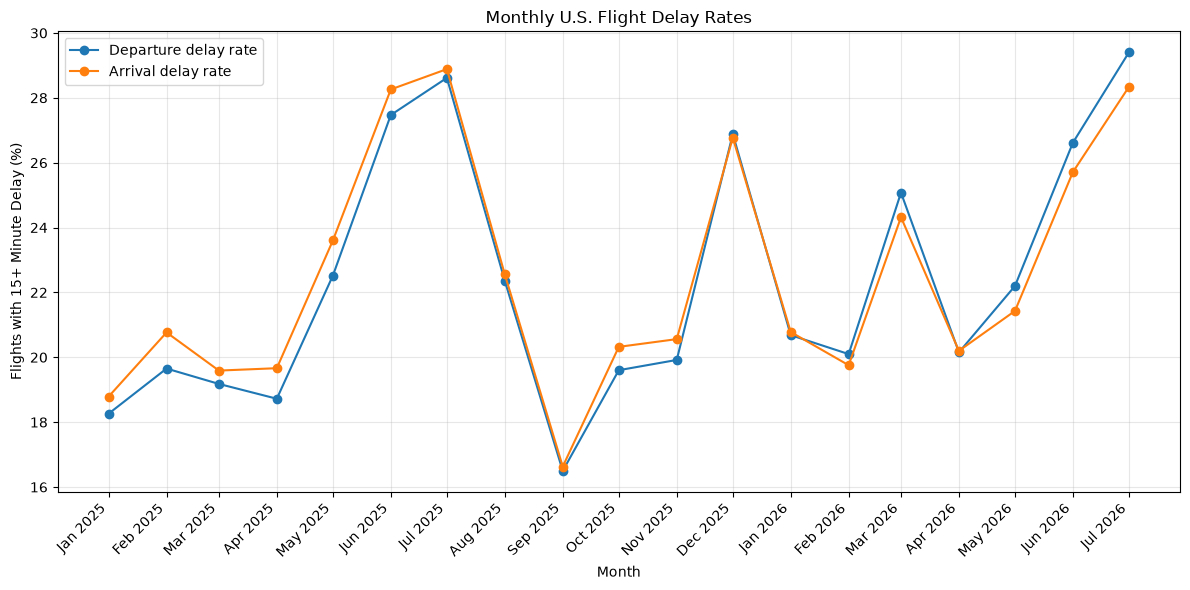

In [34]:
monthly_plot_df = monthly_performance_df.copy()

monthly_plot_df["departure_delay_pct"] = monthly_plot_df["departure_delay_rate"] * 100

monthly_plot_df["arrival_delay_pct"] = monthly_plot_df["arrival_delay_rate"] * 100

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_plot_df["month"],
    monthly_plot_df["departure_delay_pct"],
    marker="o",
    label="Departure delay rate",
)

plt.plot(
    monthly_plot_df["month"],
    monthly_plot_df["arrival_delay_pct"],
    marker="o",
    label="Arrival delay rate",
)

plt.title("Monthly U.S. Flight Delay Rates")
plt.xlabel("Month")
plt.ylabel("Flights with 15+ Minute Delay (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.xticks(
    monthly_plot_df["month"],
    monthly_plot_df["month"].dt.strftime("%b %Y"),
    rotation=45,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "monthly_delay_rates.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()



In [31]:
highest_arrival_delay_month = monthly_performance_df.loc[monthly_performance_df["arrival_delay_rate"].idxmax()]
lowest_arrival_delay_month = monthly_performance_df.loc[monthly_performance_df["arrival_delay_rate"].idxmin()]

print(
    "Highest arrival delay rate: ",
    highest_arrival_delay_month["month"].strftime("%B %Y"),
    f"{highest_arrival_delay_month['arrival_delay_rate']:.1%}"
)

print(
    "Lowest arrival delay rate:",
    lowest_arrival_delay_month["month"].strftime("%B %Y"),
    f"({lowest_arrival_delay_month['arrival_delay_rate']:.1%})",
)

Highest arrival delay rate:  July 2025 28.9%
Lowest arrival delay rate: September 2025 (16.6%)


**Figure 1. Monthly flight delay rates.** Departure and arrival delay rates varied substantially over the analysis period and generally moved together. The arrival delay rate reached its highest value in July 2025 at 28.9% and its lowest value in September 2025 at 16.6%, a difference of 12.3 percentage points. Elevated delay rates are visible during June and July in both years, while December 2025 also shows a pronounced increase. The repeated summer pattern suggests that seasonality may contribute to operational reliability, although the 19-month analysis period is too short to establish a long-term seasonal relationship.

### 5.2 Arrival Delay Rates by Airline

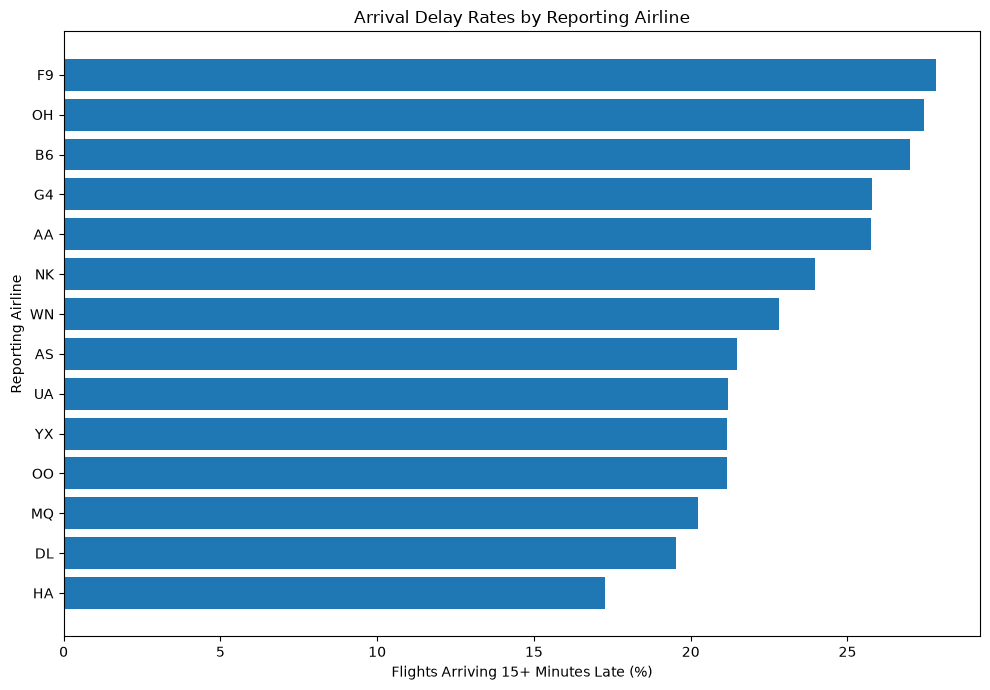

In [43]:
carrier_plot_df = (
    carrier_performance_df
    .sort_values("arrival_delay_rate", ascending=True)
    .copy()
)

carrier_plot_df["arrival_delay_pct"] = (
    carrier_plot_df["arrival_delay_rate"] * 100
)

plt.figure(figsize=(10, 7))

plt.barh(
    carrier_plot_df["Reporting_Airline"],
    carrier_plot_df["arrival_delay_pct"],
)

plt.title("Arrival Delay Rates by Reporting Airline")
plt.xlabel("Flights Arriving 15+ Minutes Late (%)")
plt.ylabel("Reporting Airline")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "carrier_arrival_delay_rates.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    PROJECT_ROOT / "figures" / "arrival_delay_rates_by_carrier.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

In [42]:
highest_carrier_delay = carrier_performance_df.loc[
    carrier_performance_df["arrival_delay_rate"].idxmax()
]

lowest_carrier_delay = carrier_performance_df.loc[
    carrier_performance_df["arrival_delay_rate"].idxmin()
]

print(
    "Highest arrival delay rate:",
    highest_carrier_delay["Reporting_Airline"],
    f"({highest_carrier_delay['arrival_delay_rate']:.1%})",
)

print(
    "Lowest arrival delay rate:",
    lowest_carrier_delay["Reporting_Airline"],
    f"({lowest_carrier_delay['arrival_delay_rate']:.1%})",
)

Highest arrival delay rate: F9 (27.8%)
Lowest arrival delay rate: HA (17.3%)


**Figure 2. Arrival delay rates by reporting airline.** Arrival reliability varied substantially across carriers during the January 2025 through July 2026 period. F9 had the highest share of flights arriving at least 15 minutes late at 27.8%, while HA had the lowest at 17.3%, a difference of about 10.6 percentage points. These differences describe observed carrier-level performance but do not by themselves establish that carrier operations caused the variation, because route mix, airport congestion, weather exposure, schedule structure, and other operational factors may differ across airlines.

### 5.3 Airport Departure Delay Rates

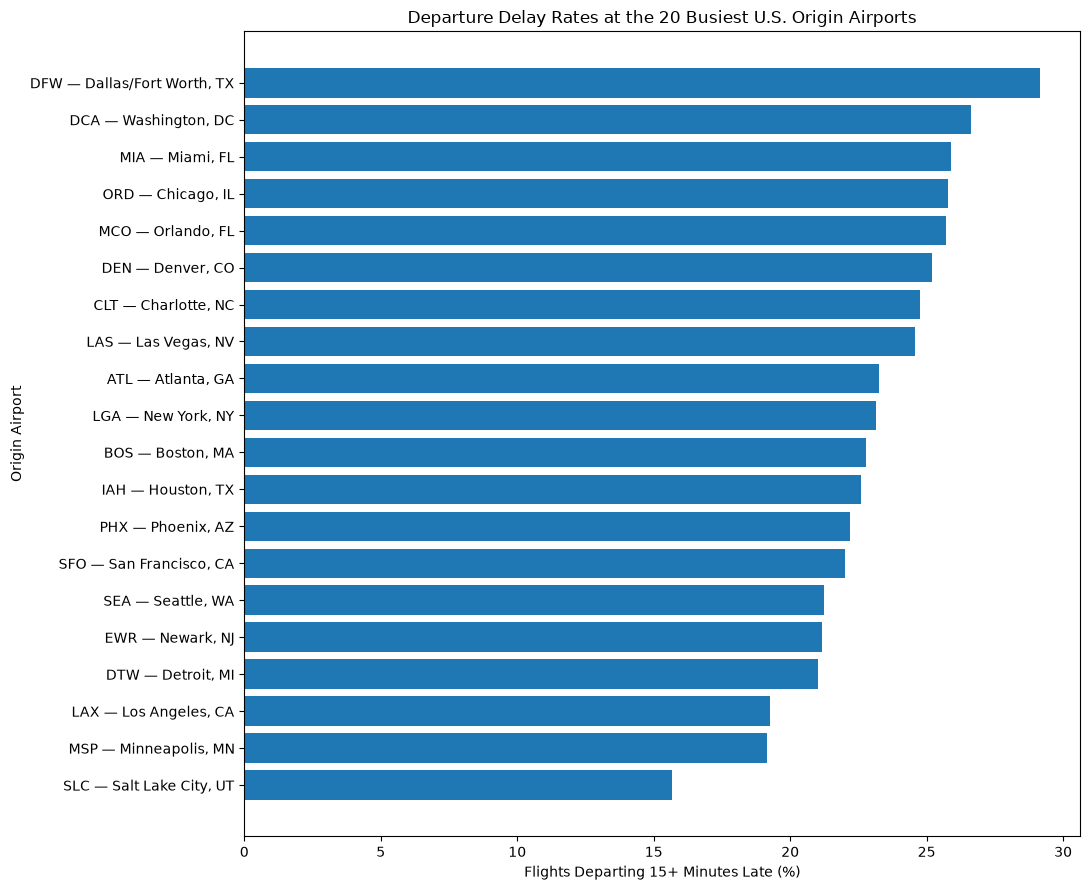

In [49]:
airport_plot_df = (
    busiest_airports_df
    .sort_values("departure_delay_rate", ascending=True)
    .copy()
)

airport_plot_df["departure_delay_pct"] = (
    airport_plot_df["departure_delay_rate"] * 100
)

airport_plot_df["airport_label"] = (
    airport_plot_df["Origin"]
    + " — "
    + airport_plot_df["OriginCityName"]
)

plt.figure(figsize=(11, 9))

plt.barh(
    airport_plot_df["airport_label"],
    airport_plot_df["departure_delay_pct"],
)

plt.title("Departure Delay Rates at the 20 Busiest U.S. Origin Airports")
plt.xlabel("Flights Departing 15+ Minutes Late (%)")
plt.ylabel("Origin Airport")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "airport_departure_delay_rates.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [50]:
highest_airport_delay = busiest_airports_df.loc[
    busiest_airports_df["departure_delay_rate"].idxmax()
]

lowest_airport_delay = busiest_airports_df.loc[
    busiest_airports_df["departure_delay_rate"].idxmin()
]

delay_rate_difference = (
    highest_airport_delay["departure_delay_rate"]
    - lowest_airport_delay["departure_delay_rate"]
)

print(
    "Highest departure delay rate:",
    highest_airport_delay["Origin"],
    f"({highest_airport_delay['departure_delay_rate']:.1%})",
)

print(
    "Lowest departure delay rate:",
    lowest_airport_delay["Origin"],
    f"({lowest_airport_delay['departure_delay_rate']:.1%})",
)

print(
    "Difference:",
    f"{delay_rate_difference * 100:.1f} percentage points",
)

Highest departure delay rate: DFW (29.2%)
Lowest departure delay rate: SLC (15.7%)
Difference: 13.5 percentage points


**Figure 3. Departure delay rates at the 20 busiest U.S.** origin airports. Delay performance varied substantially even among airports with consistently high flight volumes. Dallas/Fort Worth (DFW) had the highest departure-delay rate at 29.2%, while Salt Lake City (SLC) had the lowest at 15.7%, a difference of approximately 13.5 percentage points. The variation indicates that high traffic volume alone does not explain airport reliability; differences in airline mix, route structure, weather exposure, scheduling, airport capacity, and other operational conditions may also contribute.

## 6. Summary & Interpretation
---